# Rule-based filtering + Keras MLP

Drops rows that are always non-attack (by `http_referer`, `upstream_addr`, HEAD requests, known safe users), trains a 3-layer SELU MLP on the numeric log features and writes a submission.

In [ ]:
DATA_DIR = "../data"
SUBMISSION_DIR = "../data/submissions"

In [57]:
import pandas as pd
import numpy as np

In [244]:
train = pd.read_csv(f"{DATA_DIR}/train.csv")
train

,id,timestamp,remote_addr,remote_user,hostname,time_local,request,status,body_bytes_sent,http_referer,...,upstream_connect_time,upstream_header_time,upstream_response_time,upstream_addr,upstream_status,connection,connection_requests,data.srcip,agent.ip,rule.mitre.tactic
0,0,"Aug 29, 2023 @ 17:00:03.058",114.4.220.184,-,vm-director-nginx,30/Aug/2023:00:00:02 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0.001,0.002,0.002,10.45.184.148:32442,404,688306444,2,114.4.220.184,192.168.1.99,"[""non-attack""]"
1,1,"Aug 29, 2023 @ 17:00:33.070",10.200.160.148,-,vm-director-nginx,30/Aug/2023:00:00:31 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0,0.002,0.002,10.45.184.154:32442,404,688306865,2,10.200.160.148,192.168.1.99,"[""non-attack""]"
2,2,"Aug 29, 2023 @ 17:00:33.072",180.248.46.18,-,vm-director-nginx,30/Aug/2023:00:00:31 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0.001,0.002,0.002,10.45.184.148:32442,404,688306855,2,180.248.46.18,192.168.1.99,"[""non-attack""]"
3,3,"Aug 29, 2023 @ 17:00:33.076",125.166.3.1,-,vm-director-nginx,30/Aug/2023:00:00:32 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0,0.002,0.002,10.45.184.154:32442,404,688306869,2,125.166.3.1,192.168.1.99,"[""non-attack""]"
4,4,"Aug 29, 2023 @ 17:00:59.118",103.108.23.13,-,vm-director-nginx,30/Aug/2023:00:00:58 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0.001,0.003,0.003,10.45.184.154:32442,404,688307225,2,103.108.23.13,192.168.1.99,"[""non-attack""]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54475,54475,"Sep 5, 2023 @ 00:26:40.840",202.80.216.211,-,vm-director-nginx,05/Sep/2023:07:26:39 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0,0.002,0.002,10.45.184.154:32442,404,721724820,2,202.80.216.211,192.168.1.99,"[""non-attack""]"
54476,54476,"Sep 5, 2023 @ 00:26:40.880",114.5.245.55,-,vm-director-nginx,05/Sep/2023:07:26:40 +0700,GET /.well-known/assetlinks.json HTTP/2.0,404,74,-,...,0,0.001,0.001,10.45.184.154:32442,404,721725022,1,114.5.245.55,192.168.1.99,"[""non-attack""]"
54477,54477,"Sep 5, 2023 @ 00:26:40.907",114.5.245.55,-,vm-director-nginx,05/Sep/2023:07:26:40 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0.001,0.002,0.002,10.45.184.154:32442,404,721725023,2,114.5.245.55,192.168.1.99,"[""non-attack""]"
54478,54478,"Sep 5, 2023 @ 00:26:40.913",10.27.97.71,-,vm-director-nginx,05/Sep/2023:07:26:40 +0700,GET /auth/resources/ofl9o/login/ub/ HTTP/2.0,404,118,-,...,0.001,0.002,0.002,10.45.184.148:32442,404,721725017,2,10.27.97.71,192.168.1.99,"[""non-attack""]"


In [5]:
train.columns

Index(['id', 'timestamp', 'remote_addr', 'remote_user', 'hostname',
       'time_local', 'request', 'status', 'body_bytes_sent', 'http_referer',
       'http_user_agent', 'http_x_forwarded_for', 'time_iso8601',
       'request_method', 'request_length', 'bytes_sent', 'http_referer2',
       'request_time', 'upstream_connect_time', 'upstream_header_time',
       'upstream_response_time', 'upstream_addr', 'upstream_status',
       'connection', 'connection_requests', 'data.srcip', 'agent.ip',
       'rule.mitre.tactic'],
      dtype='object')

In [245]:
train['rule.mitre.tactic'] = train['rule.mitre.tactic'].str.replace(r'[\[\]"]', '', regex=True)

In [246]:
train['rule.mitre.tactic'].value_counts()

non-attack           52101
Impact                1784
Reconnaissance         561
Defense Evasion         29
Initial Access           4
Credential Access        1
Name: rule.mitre.tactic, dtype: int64

In [247]:
#Time local
train['timestamp'] = pd.to_datetime(train['timestamp'], format='%b %d, %Y @ %H:%M:%S.%f')

# Create a new column 'hour' containing the hour component
train['hour'] = train['timestamp'].dt.hour

In [248]:
train = train[~train['status'].isin([405, 407, 413, 422, 500, 502, 504])]

In [249]:
cross_tab = pd.crosstab(train['http_referer'], train['rule.mitre.tactic'])
cross_tab
# Filter rows where only the 'non attack' column has values greater than 0
cross_tab[(cross_tab["non-attack"] > 0) & (cross_tab.drop(columns="non-attack").eq(0).all(axis=1))]
# Filter rows where only the 'non attack' column has values greater than 0
non_attack_http = cross_tab[(cross_tab["non-attack"] > 0) & (cross_tab.drop(columns="non-attack").eq(0).all(axis=1))]
non_attack_http_list = non_attack_http.index.tolist()


In [250]:
train = train[~train['http_referer'].isin(non_attack_http_list)]

In [251]:
train = train[~train['request_method'].isin(["HEAD"])]

In [252]:
train = train[~train['remote_user'].isin(["GapuraUb2020-Mobile", "google-oauth-client"])]

In [253]:
cross_tab = pd.crosstab(train['upstream_addr'], train['rule.mitre.tactic'])

# Filter rows where only the 'non attack' column has values greater than 0
cross_tab[(cross_tab["non-attack"] > 0) & (cross_tab.drop(columns="non-attack").eq(0).all(axis=1))]
# Filter rows where only the 'non attack' column has values greater than 0
upstream_addr_nonattack = cross_tab[(cross_tab["non-attack"] > 0) & (cross_tab.drop(columns="non-attack").eq(0).all(axis=1))]
upstream_addr_list = upstream_addr_nonattack.index.tolist()
upstream_addr_list

['175.45.184.137:80',
 '175.45.184.237:80',
 '175.45.184.241:80',
 '175.45.184.242:80',
 '175.45.184.243:80']

In [254]:
train = train[~train['upstream_addr'].isin(upstream_addr_list)]

In [255]:
train = train[~train['rule.mitre.tactic'].isin(['Credential Access'])]

In [256]:
# Drop useless column
train_drop = train.drop(['timestamp', 'remote_addr', 'remote_user', 'hostname', 'time_local', 'request', 'http_referer', 'http_user_agent', 'http_x_forwarded_for', 'time_iso8601', 'http_referer2', 'upstream_addr', 'upstream_status', 'connection', 'data.srcip', 'agent.ip'], axis=1)

In [257]:
train_drop.columns

Index(['id', 'status', 'body_bytes_sent', 'request_method', 'request_length',
       'bytes_sent', 'request_time', 'upstream_connect_time',
       'upstream_header_time', 'upstream_response_time', 'connection_requests',
       'rule.mitre.tactic', 'hour'],
      dtype='object')

In [258]:
train_drop.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52768 entries, 0 to 54479
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      52768 non-null  int64  
 1   status                  52768 non-null  int64  
 2   body_bytes_sent         52768 non-null  int64  
 3   request_method          52768 non-null  object 
 4   request_length          52768 non-null  int64  
 5   bytes_sent              52768 non-null  int64  
 6   request_time            52768 non-null  float64
 7   upstream_connect_time   52768 non-null  object 
 8   upstream_header_time    52768 non-null  object 
 9   upstream_response_time  52768 non-null  object 
 10  connection_requests     52768 non-null  int64  
 11  rule.mitre.tactic       52768 non-null  object 
 12  hour                    52768 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.6+ MB


In [259]:
def clean_upstream_connect_time(x):
   x = x.split(', ')
   for i in range(len(x)):
       try:
           x[i] = float(x[i])
       except ValueError:
           x[i] = 0
   return np.max(x)

train_drop['upstream_connect_time'] = train_drop['upstream_connect_time'].apply(clean_upstream_connect_time)
train_drop['upstream_header_time'] = train_drop['upstream_header_time'].apply(clean_upstream_connect_time)
train_drop['upstream_response_time'] = train_drop['upstream_response_time'].apply(clean_upstream_connect_time)


In [260]:
train_drop.columns

Index(['id', 'status', 'body_bytes_sent', 'request_method', 'request_length',
       'bytes_sent', 'request_time', 'upstream_connect_time',
       'upstream_header_time', 'upstream_response_time', 'connection_requests',
       'rule.mitre.tactic', 'hour'],
      dtype='object')

In [261]:
hasil_one_hot = pd.get_dummies(train_drop['request_method'], prefix='request_method')

In [263]:
hasil_one_hot.head()

,request_method_GET,request_method_POST
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [264]:
train_drop = pd.concat([train_drop.drop(columns=["request_method"]), hasil_one_hot], axis=1)

In [265]:
hasil_one_hot = pd.get_dummies(train_drop['status'], prefix='status')

In [266]:
hasil_one_hot.head()

,status_200,status_301,status_302,status_303,status_400,status_403,status_404
0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,1
2,0,0,0,0,0,0,1
3,0,0,0,0,0,0,1
4,0,0,0,0,0,0,1


In [267]:
train_drop = pd.concat([train_drop.drop(columns=["status"]), hasil_one_hot], axis=1)

In [268]:
train_drop.columns

Index(['id', 'body_bytes_sent', 'request_length', 'bytes_sent', 'request_time',
       'upstream_connect_time', 'upstream_header_time',
       'upstream_response_time', 'connection_requests', 'rule.mitre.tactic',
       'hour', 'request_method_GET', 'request_method_POST', 'status_200',
       'status_301', 'status_302', 'status_303', 'status_400', 'status_403',
       'status_404'],
      dtype='object')

In [269]:
from sklearn.preprocessing import LabelEncoder  
le = LabelEncoder()
train_drop["rule.mitre.tactic"]= le.fit_transform(train_drop["rule.mitre.tactic"])

In [270]:
train_ids = train_drop['id']
train_drop.drop('id',axis=1, inplace=True)

In [271]:
# Memisahkan antara fitur dan target
target = train_drop['rule.mitre.tactic'] 
ohetarget = pd.get_dummies(target, columns=["rule.mitre.tactic"]) # ohe: One Hot Encoding
train_drop.drop('rule.mitre.tactic',axis=1, inplace=True)

In [272]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Melakukan scaling data
scaler=StandardScaler()
train_drop=pd.DataFrame(scaler.fit_transform(train_drop), columns=train_drop.columns)

# Melakukan splitting menjadi train dan validation 
# X_train, X_valid, y_train, y_valid = train_test_split(train_drop, target, 
#                                                     test_size=0.2, random_state=1)
X_train, X_valid, ohe_train, ohe_valid = train_test_split(train_drop, ohetarget, 
                                                    test_size=0.2, random_state=1, stratify=ohetarget)

print(X_train.shape, ohe_train.shape)
print(X_valid.shape, ohe_valid.shape)

(42214, 18) (42214, 5)
(10554, 18) (10554, 5)


In [273]:
X_train.columns

Index(['body_bytes_sent', 'request_length', 'bytes_sent', 'request_time',
       'upstream_connect_time', 'upstream_header_time',
       'upstream_response_time', 'connection_requests', 'hour',
       'request_method_GET', 'request_method_POST', 'status_200', 'status_301',
       'status_302', 'status_303', 'status_400', 'status_403', 'status_404'],
      dtype='object')

In [105]:
train_drop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52768 entries, 0 to 52767
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   status                  52768 non-null  float64
 1   body_bytes_sent         52768 non-null  float64
 2   request_length          52768 non-null  float64
 3   bytes_sent              52768 non-null  float64
 4   request_time            52768 non-null  float64
 5   upstream_connect_time   52768 non-null  float64
 6   upstream_header_time    52768 non-null  float64
 7   upstream_response_time  52768 non-null  float64
 8   connection_requests     52768 non-null  float64
 9   hour                    52768 non-null  float64
 10  request_method_GET      52768 non-null  float64
 11  request_method_POST     52768 non-null  float64
dtypes: float64(12)
memory usage: 4.8 MB


In [274]:
# Menggunakan fungsi Callback

from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import TensorBoard
from keras import backend as K

# Fungsi callback untuk memplotting loss
tensor_board = TensorBoard(log_dir='./Graph', histogram_freq=1,
                            write_graph=True, write_images=True)

# Fungsi callback untuk mereduksi learning rate bila tidak mengalami penurunan loss
reduce_lr = ReduceLROnPlateau(
    monitor = 'loss', 
    factor = 0.4,   
    patience = 5, 
    verbose = 1)

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [275]:
import keras
from keras.models import Sequential
from keras.layers import Dropout, BatchNormalization
from keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, Adadelta, RMSprop

model2 = Sequential()
model2.add(Dense(256, input_shape = (18,), activation = "selu"))

model2.add(Dropout(0.1))
model2.add(BatchNormalization())
model2.add(Dense(256, activation = "selu"))

model2.add(Dropout(0.1))
model2.add(BatchNormalization())
model2.add(Dense(128, activation = "selu"))

model2.add(Dropout(0.05))
model2.add(Dense(5, activation = "softmax"))
model2.compile(SGD(lr = 0.01), "categorical_crossentropy", metrics=['accuracy', f1_m])

model2.summary()

model2.fit(X_train, ohe_train, verbose=1, epochs=10, validation_split = 0.2, callbacks = [reduce_lr,tensor_board])
deep1 = model2.predict(X_valid)
deep1 = np.argmax(deep1, axis=1)
# print(accuracy_score(y_valid, deep1))

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            (None, 256)               4864      
                                                                 
 dropout_27 (Dropout)        (None, 256)               0         
                                                                 
 batch_normalization_18 (Bat  (None, 256)              1024      
 chNormalization)                                                
                                                                 
 dense_37 (Dense)            (None, 256)               65792     
                                                                 
 dropout_28 (Dropout)        (None, 256)               0         
                                                                 
 batch_normalization_19 (Bat  (None, 256)              1024      
 chNormalization)                                     

/opt/conda/envs/tf-torch/lib/python3.10/site-packages/keras/optimizer_v2/gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


1056/1056 [==============================] - 6s 5ms/step - loss: 0.1230 - accuracy: 0.9769 - f1_m: 0.9751 - val_loss: 0.0607 - val_accuracy: 0.9904 - val_f1_m: 0.9905 - lr: 0.0100
Epoch 2/10
1056/1056 [==============================] - 5s 5ms/step - loss: 0.0744 - accuracy: 0.9863 - f1_m: 0.9862 - val_loss: 0.0588 - val_accuracy: 0.9906 - val_f1_m: 0.9906 - lr: 0.0100
Epoch 3/10
1056/1056 [==============================] - 5s 5ms/step - loss: 0.0674 - accuracy: 0.9872 - f1_m: 0.9870 - val_loss: 0.0580 - val_accuracy: 0.9906 - val_f1_m: 0.9906 - lr: 0.0100
Epoch 4/10
1056/1056 [==============================] - 5s 5ms/step - loss: 0.0640 - accuracy: 0.9874 - f1_m: 0.9873 - val_loss: 0.0560 - val_accuracy: 0.9906 - val_f1_m: 0.9906 - lr: 0.0100
Epoch 5/10
1056/1056 [==============================] - 5s 5ms/step - loss: 0.0640 - accuracy: 0.9872 - f1_m: 0.9872 - val_loss: 0.0609 - val_accuracy: 0.9906 - val_f1_m: 0.9906 - lr: 0.0100
Epoch 6/10
1056/1056 [==============================] - 

In [142]:
deep1 = model2.predict(X_valid)
deep1 = np.argmax(deep1, axis=1)

In [143]:
deep1

array([4, 4, 4, ..., 4, 4, 4])

In [154]:
print(mapping)

{'Defense Evasion': 0, 'Impact': 1, 'Initial Access': 2, 'Reconnaissance': 3, 'non-attack': 4}


In [152]:
from sklearn.metrics import classification_report
print(classification_report(ohe_valid_list, deep1))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       1.00      1.00      1.00       357
           2       1.00      1.00      1.00         1
           3       0.50      0.01      0.02       112
           4       0.99      1.00      0.99     10078

    accuracy                           0.99     10554
   macro avg       0.70      0.60      0.60     10554
weighted avg       0.98      0.99      0.98     10554



/opt/conda/envs/tf-torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/tf-torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/tf-torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [144]:
unique_values, counts = np.unique(deep1, return_counts=True)

# Combine unique values and counts into a dictionary
value_counts = dict(zip(unique_values, counts))

# Print the value counts
print(value_counts)

{1: 357, 2: 1, 3: 2, 4: 10194}


In [145]:
ohe_valid

,0,1,2,3,4
22999,0,0,0,0,1
47974,0,0,0,0,1
54429,0,0,0,0,1
14651,0,0,0,0,1
13220,0,0,0,0,1
...,...,...,...,...,...
35847,0,0,0,0,1
17834,0,0,0,0,1
20147,0,0,0,0,1
46505,0,0,0,0,1


In [147]:
ohe_valid.columns

Int64Index([0, 1, 2, 3, 4], dtype='int64')

In [150]:
ohe_valid_list = []

In [151]:
for index, row in ohe_valid.iterrows():
    if row[0] == 1:
        ohe_valid_list.append(0)
    if row[1] == 1:
        ohe_valid_list.append(1)
    if row[2] == 1:
        ohe_valid_list.append(2)
    if row[3] == 1:
        ohe_valid_list.append(3)
    if row[4] == 1:
        ohe_valid_list.append(4)

In [153]:
mapping = dict(zip(le.classes_, range(len(le.classes_))))

In [159]:
reverse_mapping = {v: k for k, v in mapping.items()}

In [160]:
def get_real(valid_data, predict_data):
    new_valid = []
    new_predict = []
    for a,b in zip(valid_data, predict_data):
        new_valid.append(reverse_mapping[a])
        new_predict.append(reverse_mapping[b])
    return new_valid, new_predict

In [167]:
new_df = {'ohe_valid_real': ohe_valid_list_real,
        'deep1_real': deep1_real}
valid_pred_df = pd.DataFrame(new_df)
valid_pred_df.to_csv(f"{SUBMISSION_DIR}/valid_predictions_mlp.csv")


In [161]:
ohe_valid_list_real, deep1_real = get_real(ohe_valid_list, deep1)

In [162]:
from sklearn.metrics import classification_report
print(classification_report(ohe_valid_list_real, deep1_real))

                 precision    recall  f1-score   support

Defense Evasion       0.00      0.00      0.00         6
         Impact       1.00      1.00      1.00       357
 Initial Access       1.00      1.00      1.00         1
 Reconnaissance       0.50      0.01      0.02       112
     non-attack       0.99      1.00      0.99     10078

       accuracy                           0.99     10554
      macro avg       0.70      0.60      0.60     10554
   weighted avg       0.98      0.99      0.98     10554



/opt/conda/envs/tf-torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/tf-torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/tf-torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


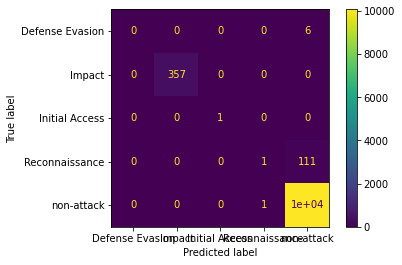

In [165]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

cm = confusion_matrix(ohe_valid_list_real, deep1_real, labels=['Defense Evasion', 'Impact', 'Initial Access', 'Reconnaissance', 'non-attack'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Defense Evasion', 'Impact', 'Initial Access', 'Reconnaissance', 'non-attack'])
disp.plot()

plt.show()

In [168]:
model2.save('my_model.h5')

In [292]:
test = pd.read_csv(f"{DATA_DIR}/test.csv")

In [293]:
#Time local
test['timestamp'] = pd.to_datetime(test['timestamp'], format='%b %d, %Y @ %H:%M:%S.%f')

# Create a new column 'hour' containing the hour component
test['hour'] = test['timestamp'].dt.hour

In [294]:
# Drop useless column
test_drop = test.drop(['timestamp', 'remote_addr', 'remote_user', 'hostname', 'time_local', 'request', 'http_referer', 'http_user_agent', 'http_x_forwarded_for', 'time_iso8601', 'http_referer2', 'upstream_addr', 'upstream_status', 'connection', 'data.srcip', 'agent.ip'], axis=1)

In [295]:
def clean_upstream_connect_time(x):
   x = x.split(', ')
   for i in range(len(x)):
       try:
           x[i] = float(x[i])
       except ValueError:
           x[i] = 0
   return np.max(x)

test_drop['upstream_connect_time'] = test_drop['upstream_connect_time'].apply(clean_upstream_connect_time)
test_drop['upstream_header_time'] = test_drop['upstream_header_time'].apply(clean_upstream_connect_time)
test_drop['upstream_response_time'] = test_drop['upstream_response_time'].apply(clean_upstream_connect_time)


In [296]:
test_drop['request_method'] = test_drop['request_method'].replace('HEAD', 'POST')

In [297]:
test_drop['request_method'].value_counts()

GET     12804
POST      795
Name: request_method, dtype: int64

In [299]:
hasil_one_hot = pd.get_dummies(test_drop['request_method'], prefix='request_method')

In [300]:
hasil_one_hot.head()

,request_method_GET,request_method_POST
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [301]:
test_drop = pd.concat([test_drop.drop(columns=["request_method"]), hasil_one_hot], axis=1)

In [302]:
test_drop['status'] = test_drop['status'].replace([405, 407, 413, 422, 416], 301)
test_drop['status'] = test_drop['status'].replace([500, 502], 302)
test_drop['status'] = test_drop['status'].replace([504], 303)

In [303]:
test_drop['status'].value_counts()

404    12722
200      656
400      152
302       33
301       29
303        6
403        1
Name: status, dtype: int64

In [304]:
hasil_one_hot = pd.get_dummies(test_drop['status'], prefix='status')

In [305]:
test_drop = pd.concat([test_drop.drop(columns=["status"]), hasil_one_hot], axis=1)

In [306]:
id_test = test_drop['id']
test_drop.drop('id',axis=1, inplace=True)

In [307]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 42214 entries, 41665 to 43786
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   body_bytes_sent         42214 non-null  float64
 1   request_length          42214 non-null  float64
 2   bytes_sent              42214 non-null  float64
 3   request_time            42214 non-null  float64
 4   upstream_connect_time   42214 non-null  float64
 5   upstream_header_time    42214 non-null  float64
 6   upstream_response_time  42214 non-null  float64
 7   connection_requests     42214 non-null  float64
 8   hour                    42214 non-null  float64
 9   request_method_GET      42214 non-null  float64
 10  request_method_POST     42214 non-null  float64
 11  status_200              42214 non-null  float64
 12  status_301              42214 non-null  float64
 13  status_302              42214 non-null  float64
 14  status_303              42214 non-

In [308]:
test_drop=pd.DataFrame(scaler.transform(test_drop), columns=test_drop.columns)

In [309]:
test_drop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13599 entries, 0 to 13598
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   body_bytes_sent         13599 non-null  float64
 1   request_length          13599 non-null  float64
 2   bytes_sent              13599 non-null  float64
 3   request_time            13599 non-null  float64
 4   upstream_connect_time   13599 non-null  float64
 5   upstream_header_time    13599 non-null  float64
 6   upstream_response_time  13599 non-null  float64
 7   connection_requests     13599 non-null  float64
 8   hour                    13599 non-null  float64
 9   request_method_GET      13599 non-null  float64
 10  request_method_POST     13599 non-null  float64
 11  status_200              13599 non-null  float64
 12  status_301              13599 non-null  float64
 13  status_302              13599 non-null  float64
 14  status_303              13599 non-null

In [310]:
hasil = model2.predict(test_drop)
hasil = np.argmax(hasil, axis=1)

In [ ]:
hasil

In [318]:
def get_real(valid_data):
    new_valid = []
    for a in valid_data:
        new_valid.append(reverse_mapping[a])
    return new_valid

In [320]:
hasil = get_real(hasil)

KeyError: 'non-attack'

In [325]:
submission = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

In [327]:
submission['rule.mitre.tactic'] = hasil

In [326]:
submission['rule.mitre.tactic'].value_counts()

["Impact"]    13599
Name: rule.mitre.tactic, dtype: int64

In [328]:
submission['rule.mitre.tactic'].value_counts()

non-attack        12887
Impact              680
Reconnaissance       29
Initial Access        3
Name: rule.mitre.tactic, dtype: int64

In [324]:
submission.to_csv(f"{SUBMISSION_DIR}/submission_mlp_rules.csv")

In [215]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13599 entries, 0 to 13598
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 13599 non-null  int64 
 1   rule.mitre.tactic  13599 non-null  object
dtypes: int64(1), object(1)
memory usage: 212.6+ KB
